<a href="https://colab.research.google.com/github/supsi-dacd-isaac/teaching/blob/main/2021SmartGrids%20/L10_final_project_introduction_with_EVs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Simulatore di impianto fotovoltaico
Questo primo esempio è un **semplice simulatore di impianto fotovoltaico**, che simula la produzione di un impianto fotovoltaico non ombreggiato, partendo da una posizione e da un file meteo che contiene T e GHI. Useremo la [libreria pvlib](https://pvlib-python.readthedocs.io/) per aiutarci con alcuni calcoli. Si tratta di una libreria di simulazione fotovoltaica molto potente che può essere utilizzata per simulare in dettaglio gli impianti fotovoltaici. Per semplicità, qui non la utilizzeremo al massimo delle sue capacità.

In [1]:
%%capture
!pip install pvlib
import pvlib
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import files
import matplotlib.pyplot as plt
import gdown
import zipfile

Per prima cosa, carichiamo il file **meteo.csv** in un dataframe pandas

In [2]:
!gdown 1Psvmk5z3zlB8YBmK5PR0vd4J0RLirgKG # download meteo data from shared gdrive file
# alternatively, to load a file from your pc unconmment the next two lines and comment the previous one
# from google.colab import files
# uploaded = files.upload()
meteo = pd.read_csv('meteo.csv', header=0, parse_dates=[0], date_format='%d-%b-%Y %H:%M:%S', index_col=0)

Downloading...
From: https://drive.google.com/uc?id=1Psvmk5z3zlB8YBmK5PR0vd4J0RLirgKG
To: /content/meteo.csv
100% 1.02M/1.02M [00:00<00:00, 39.7MB/s]


Plottiamolo

array([<Axes: xlabel='t'>, <Axes: xlabel='t'>], dtype=object)

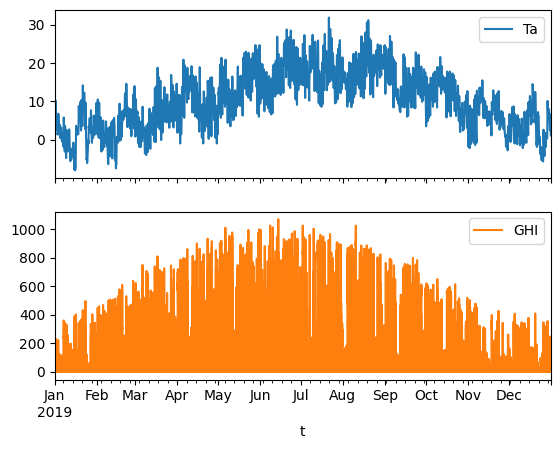

In [3]:
meteo.plot(subplots=True)

Definiamo la posizione e l'orientamento dell'impianto

In [4]:
# location
latitude = 47.03
longitude = 8.296
altitude = 460
location = pvlib.location.Location(latitude, longitude, 'Etc/GMT-1', altitude)

# PV plant
p_module = 470  # potenza del modulo
num_modules = 42  # numero di moduli
tilt = 15
azimuth = 193
albedo = 0.1 # albedo of the ground for ground reflected irradiance

Ora calcoliamo l'irraggiamento sul piano dell'array nel modo seguente:
*   Calcoliamo la posizione del sole in base alla località e all'ora
*   Dividiamo l'irradiazione solare globale (GHI) nelle sue componenti diretta e diffusa
*   E le proiettiamo sul piano dell'array (POA)

In [5]:
sun_pos = location.get_solarposition(meteo.index)
ghi = meteo['GHI']
dni = pvlib.irradiance.dirint(meteo['GHI'], sun_pos['zenith'], sun_pos.index)
dni.fillna(0, inplace=True)
dhi = ghi - np.cos(np.deg2rad(sun_pos['zenith'])) * dni


irr = pvlib.irradiance.get_total_irradiance(tilt, azimuth, sun_pos['zenith'], sun_pos['azimuth'], dni, ghi, dhi,
                                      albedo=albedo, model_perez='allsitescomposite1990')

## Calcoliamo la potenza dell'impianto fotovoltaico con un modello semplificato che tiene conto dell'angolo d'incidenza, della temperatura e dell'efficienza dell'inverter.

### Correggiamo per l'angolo di incidenza
Calcoliamo l'IAM (angle of incidence modifier)

$$ IAM(\theta) = \frac{\tau_\theta}{\tau_0} $$

utilizzando il modello [ASHRAE](https://pvpmc.sandia.gov/modeling-guide/1-weather-design-inputs/shading-soiling-and-reflection-losses/incident-angle-reflection-losses/ashrae-iam-model/)

$$ IAM_B = 1 - b_0 \left( \frac{1}{\cos(\theta_{AOI})} - 1 \right)$$

$IAM_B$: Modificatore dell’angolo di incidenza per il fascio diretto (beam)

$b_0$: Coefficiente empirico che quantifica la perdita angolare

$\theta_{AOI}$: Angolo di incidenza (AOI = Angle of Incidence)

e lo applichiamo solo alla componente diretta dell'irraggiamento
Alla componente diffusa applichiamo un fattore 0.95

In [6]:
b0 = 0.05
aoi = pvlib.irradiance.aoi(tilt, azimuth, sun_pos['zenith'], sun_pos['azimuth'])  # angle of incidence
iam = np.maximum(1 - b0 * (1 / np.cos(np.minimum(np.deg2rad(aoi), np.pi/2)) - 1), 0)
irr['poa_eff'] = iam * irr['poa_direct'] + 0.95 * (irr['poa_diffuse'])

### Correggiamo per la temperatura

Calcoliamo la temperatura della cella utilizzando il [modello Sandia](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.temperature.sapm_cell.html), che si basa su queste due equazioni empiriche:


$$T_{m} = E \cdot \exp (a + b \cdot WS) + T_{a}$$
$$T_{C} = T_{m} + \frac{E}{E_{0}} \Delta T$$

In [7]:
gamma = -0.34 / 100  # power loss as function of temperature
t_nom = 25  # nominal temperature
a=-3.56 #
b=-0.075
deltaT=3
wind_speed=1
i_stc = 1000

t_cell = pvlib.temperature.sapm_cell(irr['poa_global'], meteo['Ta'], wind_speed, a, b, deltaT, irrad_ref=i_stc)
irr['poa_eff_tc'] = irr['poa_eff'] * (1 + gamma * (t_cell - t_nom))

Quindi correggiamo l'efficienza del modulo e dell'inverter in funzione di GHI utilizzando la seguente formula (a bassi irraggiamenti l'efficienza è più bassa):

$$ \eta = k2 + k3 \cdot \log(GHI / GHI_{STC}) +k4 \cdot\log(GHI/GHI_{STC})^2 $$

In [8]:
k2 = 0.942
k3 = -5.02e-2
k4 = -3.77e-2
np.seterr(divide = 'ignore') # disable divide by zero warning
eta = np.maximum(0.1, (k2 + k3 * np.log(irr['poa_eff'] / i_stc) + k4 * np.log(irr['poa_eff'] / i_stc)**2).fillna(0))
np.seterr(divide = 'warn')
irr['poa_eff_tc_li'] = irr['poa_eff_tc'] * eta

Calcoliamo la potenza dell'impianto fotovoltaico

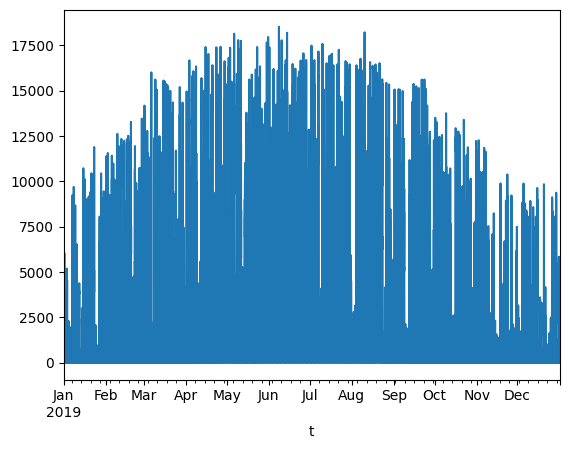

In [9]:
# power of plant in W
p_plant = p_module * irr['poa_eff_tc_li'] / 1000 * num_modules
p_plant.plot()

# calculate the energy of the plant in kWh
e_plant = p_plant / 1000 * (p_plant.index[1]- p_plant.index[0]).seconds / 3600 # W to kWh
e_plant = e_plant.tz_localize('Etc/GMT-1')

# here this is useless
save_path = 'energy_pv.csv'
e_plant.to_csv(save_path, sep=',', date_format='%Y-%m-%dT%H:%M:%S', float_format='%.03f')

# this downloads the csv file onto your local machine
# from google.colab import files
# files.download('energy_pv.csv')

# 2. Esplorazione dei dati di consumo
Nelle celle seguenti, scarichiamo i dati di consumo dagli appartamenti in un dataframe di pandas e li tracciamo


In [10]:
!gdown 1F8rP6NoZiTUsu9nNEMN3suIhStaSCn78
consumption = pd.read_csv('dati_consumo_15min.csv', header=0, parse_dates=[0], date_format='%d/%m/%Y %H:%M', index_col=0).tz_localize('Etc/GMT-1')
consumption.index -= pd.Timedelta(minutes=15) # allinea con meteo
consumption.head()

Downloading...
From: https://drive.google.com/uc?id=1F8rP6NoZiTUsu9nNEMN3suIhStaSCn78
To: /content/dati_consumo_15min.csv
100% 13.1M/13.1M [00:00<00:00, 231MB/s]


,meter_0001,meter_0002,meter_0003,meter_0004,meter_0005,meter_0006,meter_0007,meter_0008,meter_0009,meter_0010,...,meter_0021,meter_0022,meter_0023,meter_0024,meter_0025,meter_0026,meter_0027,meter_0028,meter_0029,meter_0030
time,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+01:00,0.018017,0.020275,0.021447,0.011577,0.009398,0.009164,0.008745,0.007786,0.021154,0.005755,...,0.016487,0.009100,0.018573,0.030718,0.023458,0.024895,0.022042,0.009034,0.018996,0.013450
2019-01-01 00:15:00+01:00,0.009959,0.008225,0.012203,0.015851,0.026795,0.017168,0.017885,0.007622,0.010595,0.005710,...,0.007967,0.009185,0.017974,0.028733,0.015230,0.015171,0.012482,0.016341,0.009567,0.038097
2019-01-01 00:30:00+01:00,0.009920,0.008091,0.012366,0.017200,0.016013,0.009262,0.008605,0.010487,0.010732,0.005690,...,0.007479,0.009131,0.018131,0.027909,0.015626,0.015120,0.012588,0.040415,0.009668,0.047851
2019-01-01 00:45:00+01:00,0.011537,0.008054,0.012329,0.011694,0.009429,0.009246,0.008486,0.014420,0.010446,0.005753,...,0.007439,0.017151,0.036369,0.022211,0.016980,0.019095,0.012292,0.030651,0.009534,0.050035
2019-01-01 01:00:00+01:00,0.016851,0.015236,0.022917,0.011671,0.011918,0.009063,0.008548,0.007790,0.013327,0.005644,...,0.011226,0.009225,0.028554,0.022608,0.023549,0.020699,0.022079,0.031388,0.019017,0.048181


Text(0.5, 0, 'total consumption [kWh]')

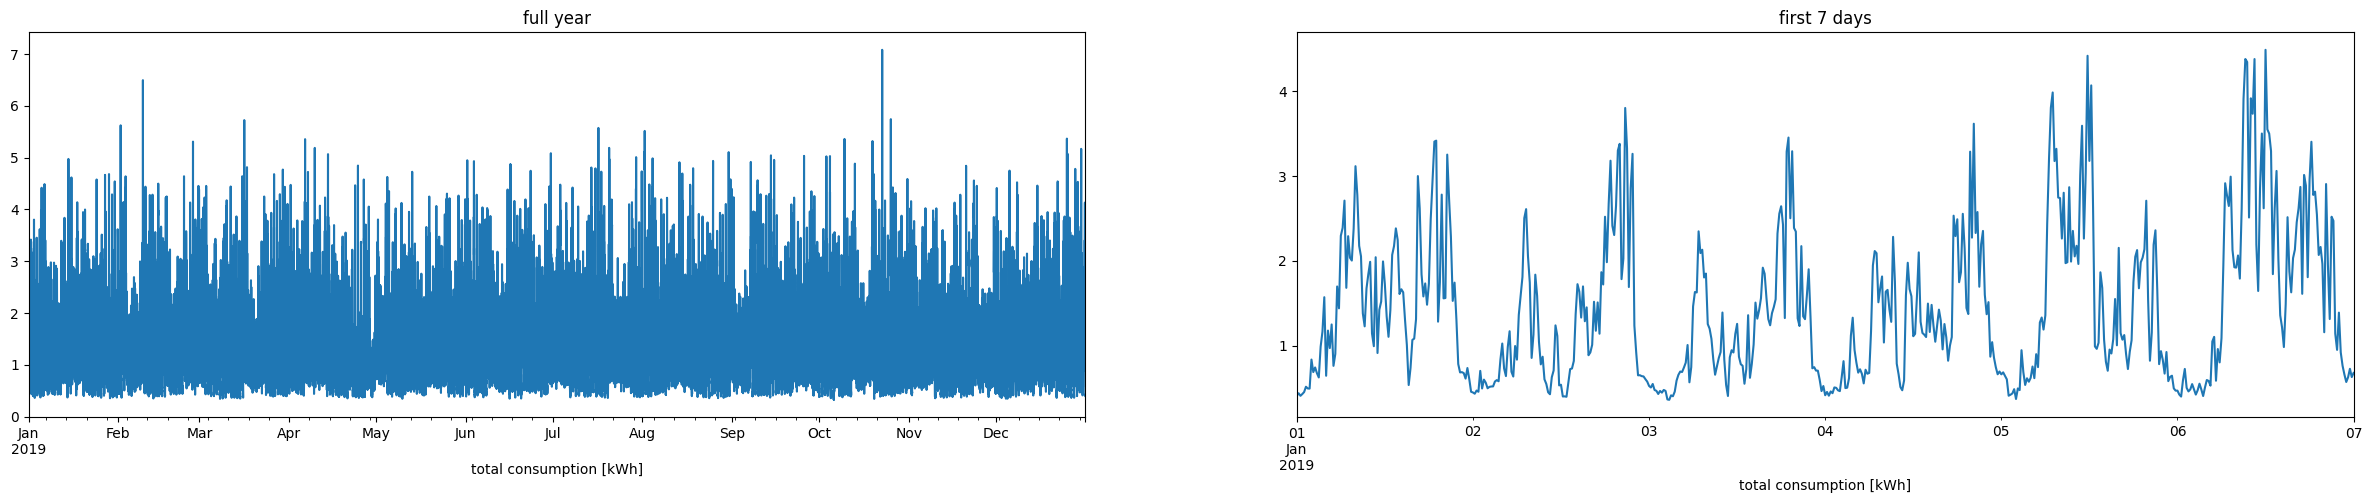

In [11]:
fig, ax = plt.subplots(1,2,figsize=(30,5))
E15 = consumption.sum(axis=1)
E15.plot(ax=ax[0])
ax[0].set_title('full year')
ax[0].set_xlabel('total consumption [kWh]')
E15.iloc[consumption.index<'2019-01-07 00:15:00'].plot(ax=ax[1])
ax[0].set_title('full year')
ax[0].set_xlabel('total consumption [kWh]')
ax[1].set_title('first 7 days')
ax[1].set_xlabel('total consumption [kWh]')

# 3. Stima del ritorno sull'investimento per l'impianto fotovoltaico
Stimiamo il ritorno sull'investimento di un impianto fotovoltaico, dati:
*  Profilo di produzione (calcolato sopra)
*  Costo dell'impianto fotovoltaico
*  Costi di funzionamento e manutenzione
*  Prezzi dell'energia
*  Autoconsumo
*  Costo del capitale
*  Durata prevista dell'impianto fotovoltaico
Per prima cosa installiamo le librerie necessarie e definiamo i parametri


In [12]:
%%capture
!pip install numpy_financial
import numpy_financial as npf  # used to calculate financial figures
o_and_m = 30  # operation and maintenace costs [CHF/kW]
wacc = 0.02  # weighted average cost of capital
life_span = 25
degradation = 0.2  # 20% after 25years

self_consumption = 0.6  # 60%
p_sell = 0.075
p_buy = 0.29
p_pv = p_buy * self_consumption + p_sell * (1 - self_consumption)

plant_size = p_module * num_modules / 1000
plant_cost = 34520

**Calcoliamo la produzione di energia fotovoltaica durante i 25 anni di vita e teniamo conto del degrado** dell'impianto fotovoltaico.
Il degrado totale dopo la vita utile dovrebbe essere del 20%, possiamo calcolare il degrado ad ogni intervallo di tempo utilizzando le seguenti formule:
$$(1-d) = (1-d_m)^{mt}$$
$$d_m = 1-(1-d)^{1/mt}$$
dove $d$ è il degrado totale alla fine della vita, $t$ è la durata in anni e $m$ è il numero di passi all'anno

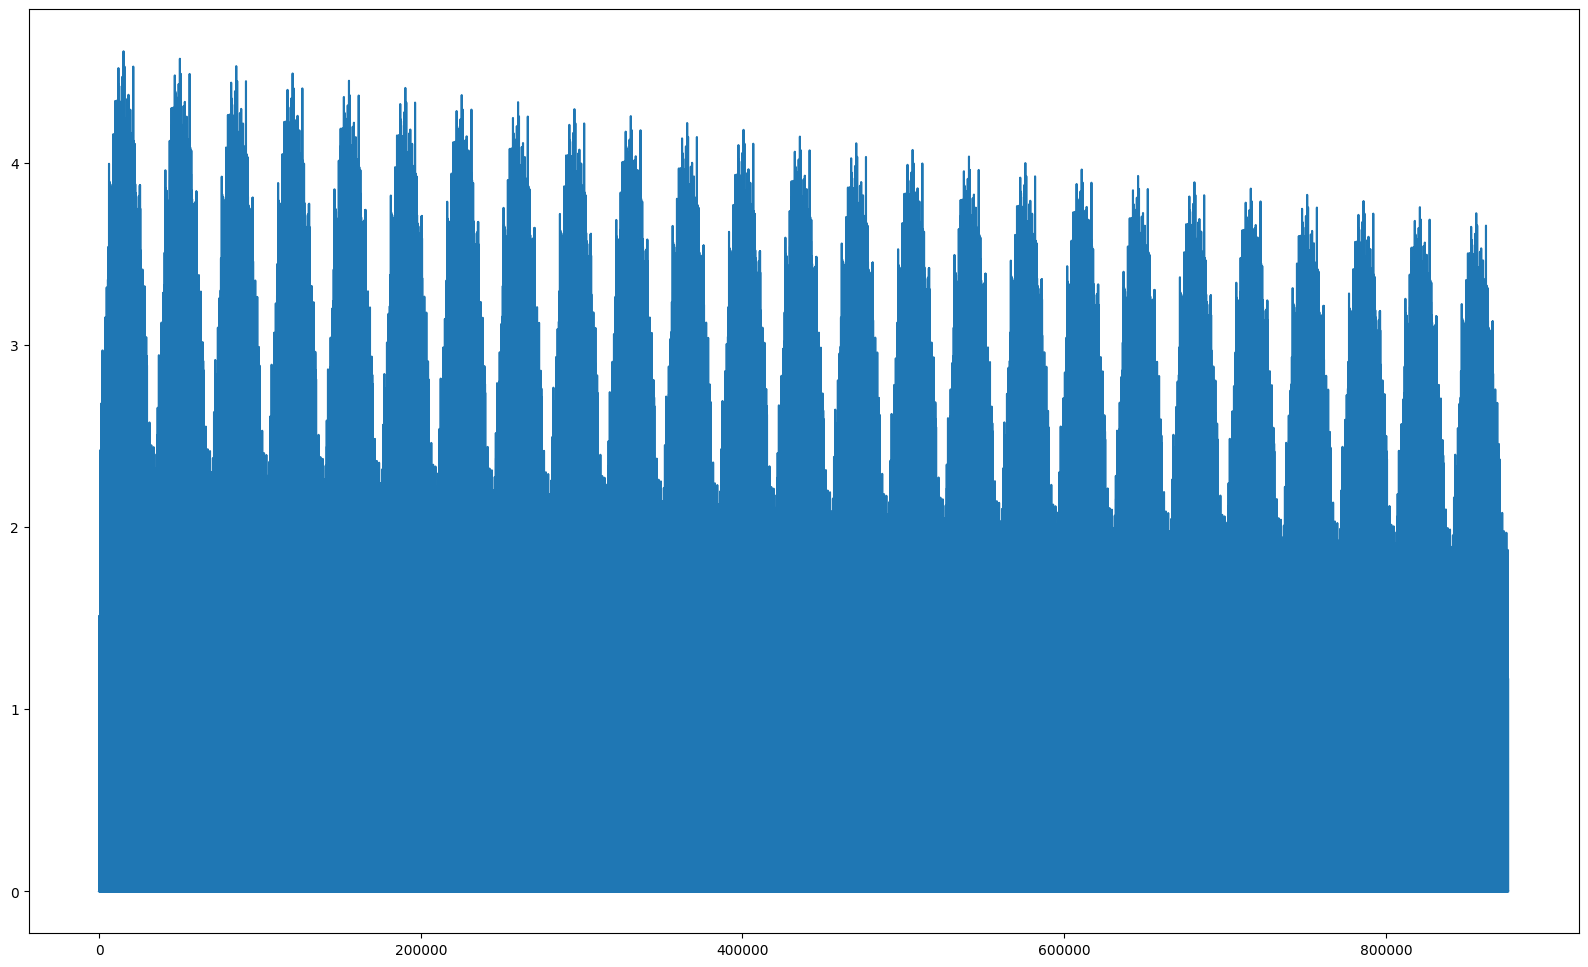

In [13]:
e_ls = np.tile(e_plant, life_span)
d_m = 1 - (1-degradation)**(1/len(e_ls))
eta = (1-d_m)**np.arange(len(e_ls))
e_ls *= eta

plt.figure(figsize=(20,12))
plt.plot(e_ls);

Ora eseguiamo un'analisi finanziaria molto semplicistica per stimare il ritorno sull'investimento.
Innanzitutto, calcoliamo tutti i costi e i ricavi. Quindi calcoliamo il flusso di cassa libero per la durata del sistema fotovoltaico e quindi calcoliamo il valore attuale netto per ogni anno per calcolare dopo quanti anni raggiungiamo una condizione di pareggio. In questa analisi molto semplice, non teniamo conto delle tasse.

**NPV:**
In economia, il valore attuale netto (abbreviato in NPV) è un metodo utilizzato per definire il valore attuale di una serie prevista di flussi di cassa non solo sommandoli nei conti, ma scontandoli sulla base del tasso di rendimento.
$${\mathrm{NPV}} (i, N) = \sum_{t=0}^N \frac{R_t}{(1+i)^t}$$

$R_t$: flusso di cassa netto al tempo t

$i$:	tasso di sconto

$N$:	numero di periodi


**IRR:**
Il tasso interno di rendimento (IRR) è il tasso di sconto che rende il valore attuale netto (NPV) di un progetto pari a zero. In altre parole, è il tasso di rendimento atteso che eguaglia il valore attuale dei flussi di cassa futuri al costo iniziale dell'investimento.

$${\mathrm{NPV}} (IRR, N) = 0$$


Discounted Payback Period 12.1 years
IRR at 25 years: 7.68%


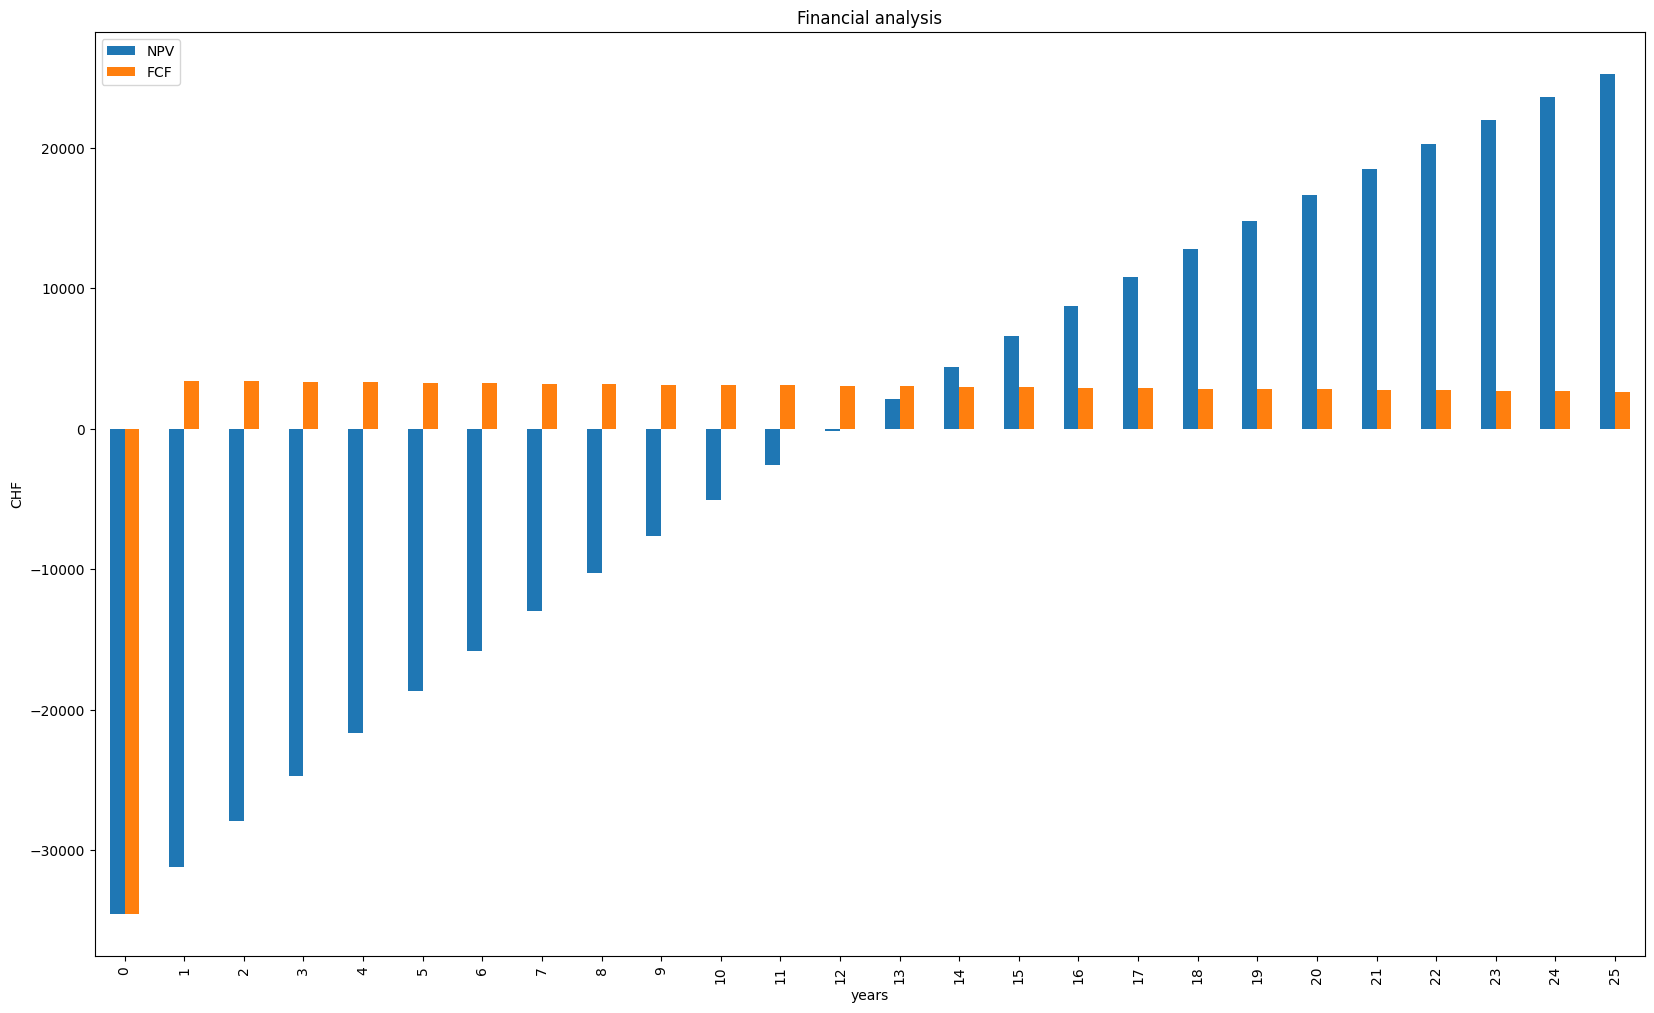

In [14]:
years = range(life_span)
capex = np.array([plant_cost])
opex = np.ones(life_span) * o_and_m * plant_size
costi = np.hstack([capex, opex])
yearly_production = np.sum(np.reshape(e_ls, (life_span, -1)), axis=1)
revenues = yearly_production * p_pv

fcf = np.hstack([0, revenues]) - costi  # free cash flow
npv = np.array([npf.npv(wacc, fcf[:i]) for i in np.arange(1, life_span + 2)])
irr = npf.irr(fcf)

financials = pd.DataFrame(data={'years': np.arange(26), 'NPV': npv, 'FCF': fcf}).set_index('years')

fig, ax = plt.subplots(1,1,figsize=(20,12))
financials.plot(kind='bar', title='Financial analysis', ax=ax).set_ylabel('CHF');

discounted_fcf = fcf / (1 + wacc) ** np.arange(len(fcf))
cumulative_dcf = np.cumsum(discounted_fcf)

if all(cumulative_dcf < 0):
    payback_time = np.nan  # Mai ripagato
else:
    payback_year = np.argmax(cumulative_dcf >= 0)
    prev = cumulative_dcf[payback_year - 1] if payback_year > 0 else 0
    frac = (0 - prev) / (cumulative_dcf[payback_year] - prev)
    payback_time = payback_year - 1 + frac

print('Discounted Payback Period {:.1f} years'.format(payback_time))
print('IRR at {} years: {:.2%}'.format(life_span, irr))

# 4. Simulazione dei profili di carica di veicoli elettrici
Come prima cosa, generiamo dei dataframes con il consumo della palazzina e la produzione PV per tutta la durata di vita dell'impianto

In [15]:
life_time_index = pd.date_range(start=consumption.index[0], periods=len(consumption)*life_span, freq='15min')
consumption_lifetime = pd.DataFrame(np.tile(consumption, (life_span, 1)), index=life_time_index, columns=consumption.columns)
production_lifetime = pd.Series(e_ls, index=consumption_lifetime.index)
prosumption_lifetime = consumption_lifetime.sum(axis=1) - production_lifetime

Dopodiché definiamo:
- L'evoluzione nel tempo della **presenza di EV** nella palazzina
- La **corrente massima** della singola colonnina in A (assumendo carica trifase)
- L'evoluzione della **potenza massima dell'allacciamento dell'edificio** in kW (possiamo pensare di aumentarla nel tempo)

In [16]:
evs_per_year = np.linspace(4, 30, life_span).astype(int)
max_A_single_charger = 16 # [6, 10, 16, 32]
max_P_building = (np.ones(life_span) * 50).astype(int) # per il momento il codice funziona solo con valori interi per la potenza massima

print(f'EVs per year: {evs_per_year}')
print(f'Max A single charger: {max_A_single_charger}')
print(f'Max P building: {max_P_building}')

EVs per year: [ 4  5  6  7  8  9 10 11 12 13 14 15 17 18 19 20 21 22 23 24 25 26 27 28
 30]
Max A single charger: 16
Max P building: [50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50
 50]


## Scarichiamo la funzione che simula la carica dei veicoli e i dati relativi ai profili di utilizzo degli stessi

In [17]:
file_id = '1BqAi3JEs-F-O3_425Twk1q-oqlFzqLlU'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, quiet=True)


file_id = '1B_DK-dEhRK1JwNdIFgoxCh6tD16B1XPZ'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'downloaded_file'  # You can customize this based on file type later

# Step 4: Download the file
gdown.download(url, output, quiet=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall()

## importiamo la funzione `generate_charge_profiles` e stampiamo l'help per capire come utilizzarla

In [18]:
from charge_profiles_generator import generate_charge_profiles
help(generate_charge_profiles)

Numba is available and will be used for acceleration
Help on function generate_charge_profiles in module charge_profiles_generator:

generate_charge_profiles(a_max_values=None, p_tot_max_values=None, start_date=None, end_date=None, num_evs=0, processes=0, df_uncontrolled=None, save_format=None, generate_plots=False, ev_profile_dir='data/profili utilizzo auto pkl/', output_dir='data/output')
    Generate EV charging profiles with specified parameters
    
    Parameters:
    -----------
    a_max_values : list of int
        List of maximum current values in Amperes (default: [6, 10, 16])
    p_tot_max_values : list of int
        List of maximum power values in kW (default: [50, 100, 1000])
    start_date : str
        Start date for processing (format: YYYY-MM-DD, default: process full year)
    end_date : str
        End date for processing (format: YYYY-MM-DD, default: process full year)
    num_evs : int
        Number of EVs to process (default: all)
    processes : int
        Nu

## Generiamo i profili di carica dei veicoli
Questa parte di codice prende parecchio tempo (calcolate poco meno di un'ora per 25 anni di `life_span`)

In [19]:
profiles = []
curtailed_charges = []
negative_soc = []
for year in range(life_span):
  print(f'Generating profiles for year {year+1}...')
  num_evs = evs_per_year[year]
  max_P_year = max_P_building[year]

  year_prosumption = prosumption_lifetime.iloc[year*len(consumption):(year+1)*len(consumption)].copy()
  year_index = year_prosumption.index.copy()
  # We have car usage profiles only for the year 2019, we'll use the 2019 index and restore it later
  year_prosumption.index = consumption.index

  # Store the result of generate_charge_profiles() in a variable
  results_gen = generate_charge_profiles(
      a_max_values=[max_A_single_charger],
      p_tot_max_values=[max_P_year],
      num_evs=num_evs,
      processes=1,
      df_uncontrolled=year_prosumption,
      generate_plots=False,
      ev_profile_dir='profili utilizzo auto/')

  # Check if the results_gen dictionary is empty before iterating
  if results_gen:
      results = next(iter(results_gen.values()))
      year_profiles = results['power_profiles']
      year_profiles.index = year_index # here we restore the correct index
      profiles.append(year_profiles)
      year_negative_soc = results['neg_soc_df'].astype(int).resample('15min').sum()
      year_negative_soc.index = year_index
      negative_soc.append(year_negative_soc)
      year_curtailed_charges = results['insufficient_charge_df'].astype(int).resample('15min').sum()
      year_curtailed_charges.index = year_index
      curtailed_charges.append(year_curtailed_charges)
  else:
      raise ValueError("No profiles generated for year {}".format(year+1))

df_profiles = pd.concat(profiles).fillna(0)
df_curtailed_charges = pd.concat(curtailed_charges).fillna(0)
df_negative_soc = pd.concat(negative_soc).fillna(0)

Generating profiles for year 1...
Ad: [[1.]]
Bd: [[ 56.99998 -63.15787]]
Loading EV profiles...
Processing 4 EV profiles...


Processing files:   0%|          | 0/4 [00:00<?, ?it/s]

Concatenating dataframes...
Using 1 processes
Processing sequentially (single process)
Processing with a_max=16, p_tot_max=50


Processing a_max=16, p_tot_max=50:   0%|          | 0/525600 [00:00<?, ?it/s]

All processing completed
Generating profiles for year 2...
Ad: [[1.]]
Bd: [[ 56.99998 -63.15787]]
Loading EV profiles...
Processing 5 EV profiles...


...

All processing completed
Generating profiles for year 25...
Ad: [[1.]]
Bd: [[ 56.99998 -63.15787]]
Loading EV profiles...
Processing 30 EV profiles...


Processing files:   0%|          | 0/30 [00:00<?, ?it/s]

Concatenating dataframes...
Using 1 processes
Processing sequentially (single process)
Processing with a_max=16, p_tot_max=50


Processing a_max=16, p_tot_max=50:   0%|          | 0/525600 [00:00<?, ?it/s]

All processing completed


## Verifichiamo se limitiamo la carica
Plottiamo i momenti un cui i veicoli non si sono caricati a potenza nominale

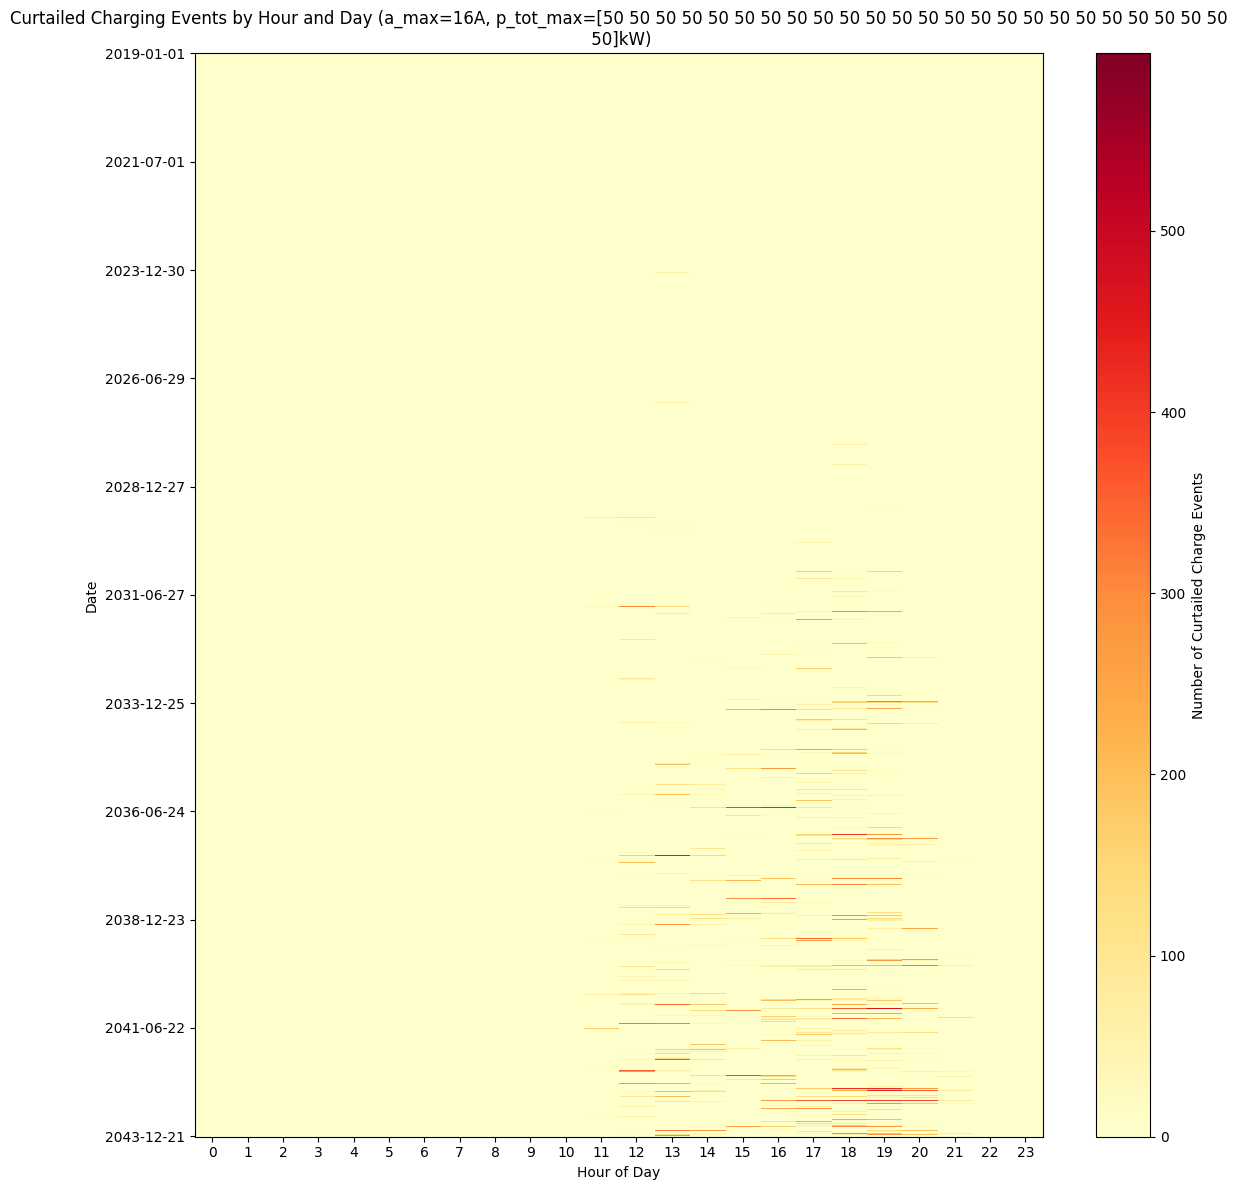

In [27]:
plt.figure(figsize=(12, 12))
# Sum across all EVs to get total insufficient charge events at each timestamp
total_curtailed_series = df_curtailed_charges.sum(axis=1)
# Create a pivot table with hours as columns and days as rows
hourly_data = total_curtailed_series.groupby([
    total_curtailed_series.index.date,
    total_curtailed_series.index.hour
]).sum().unstack()
# Plot heatmap
if not hourly_data.empty:
    plt.imshow(hourly_data, aspect='auto', cmap='YlOrRd', interpolation='none')
    plt.colorbar(label='Number of Curtailed Charge Events')
    plt.title(f'Curtailed Charging Events by Hour and Day (a_max={max_A_single_charger}A, p_tot_max={max_P_building}kW)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Date')
    # Set x-ticks to hours
    plt.xticks(range(24), range(24))
    # Format y-ticks as dates (show fewer for readability)
    date_indices = list(range(0, len(hourly_data.index), max(1, len(hourly_data.index)//10)))
    plt.yticks(date_indices, [str(d)[:10] for d in hourly_data.index[date_indices]])
    plt.tight_layout()

## Verifichiamo se soddisfiamo il fabbisogno di carica
Plottiamo quante volte i veicoli si sono scaricati prima di poter essere ricaricati

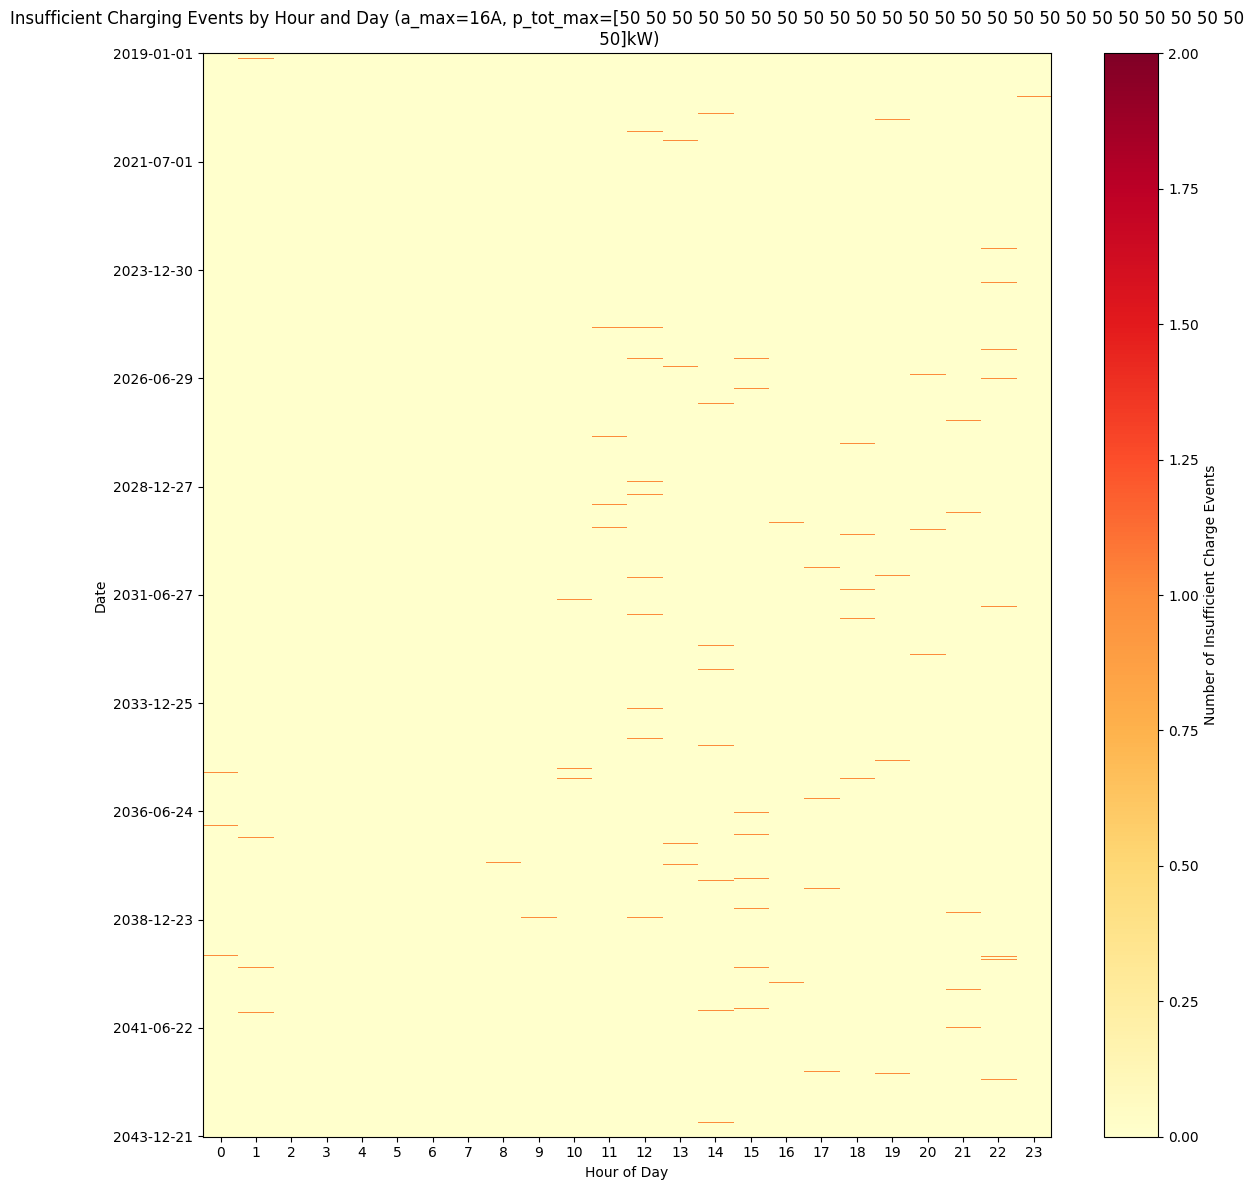

In [21]:
plt.figure(figsize=(12, 12))
# Sum across all EVs to get total insufficient charge events at each timestamp
total_insufficient_series = df_negative_soc.sum(axis=1)
# Create a pivot table with hours as columns and days as rows
hourly_data = total_insufficient_series.groupby([
    total_insufficient_series.index.date,
    total_insufficient_series.index.hour
]).sum().unstack()
# Plot heatmap
if not hourly_data.empty:
    plt.imshow(hourly_data, aspect='auto', cmap='YlOrRd', interpolation='none')
    plt.colorbar(label='Number of Insufficient Charge Events')
    plt.title(f'Insufficient Charging Events by Hour and Day (a_max={max_A_single_charger}A, p_tot_max={max_P_building}kW)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Date')
    # Set x-ticks to hours
    plt.xticks(range(24), range(24))
    # Format y-ticks as dates (show fewer for readability)
    date_indices = list(range(0, len(hourly_data.index), max(1, len(hourly_data.index)//10)))
    plt.yticks(date_indices, [str(d)[:10] for d in hourly_data.index[date_indices]])
    plt.tight_layout()

## Plottiamo la carica dei singoli veicoli durante il primo e l'ultimo mese del dataset

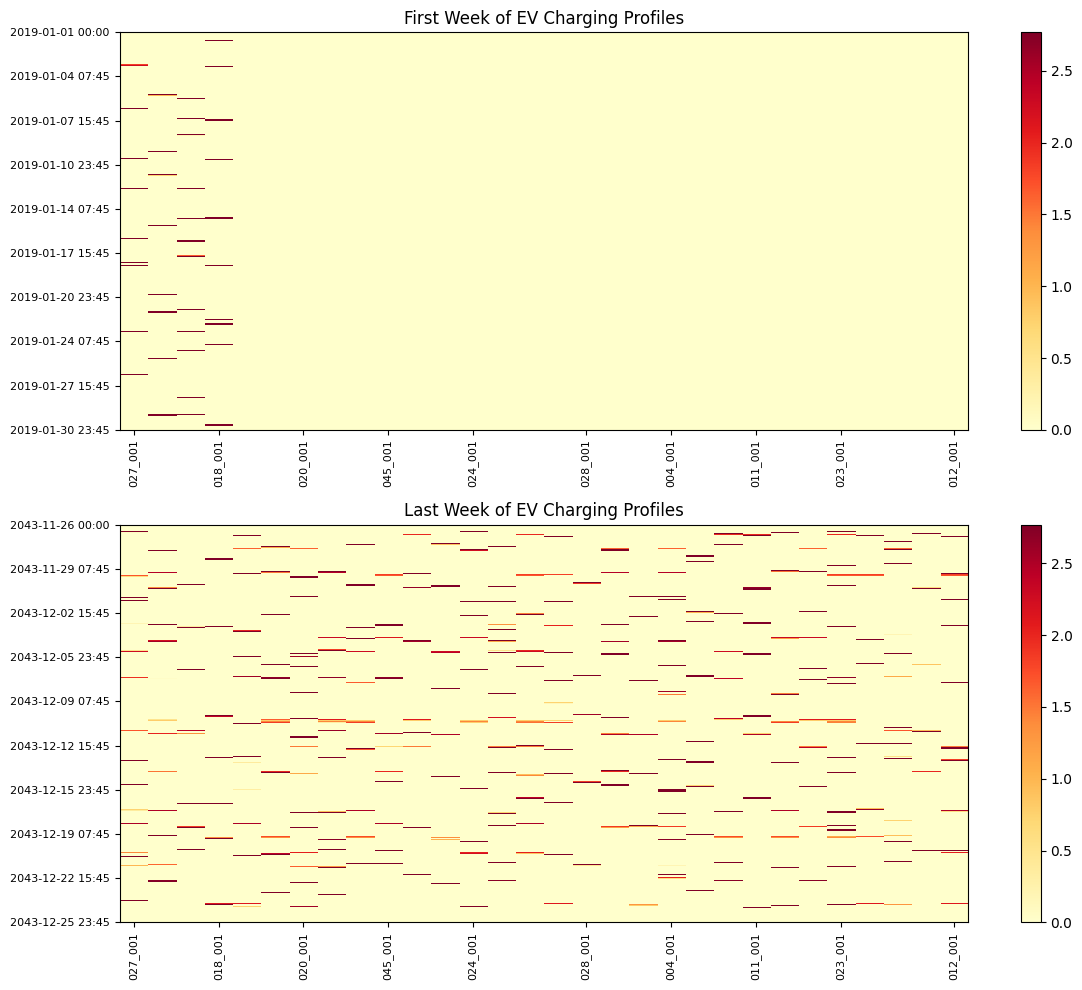

In [22]:
# Extract the first and last "week" of data based on your criteria.
first_week = df_profiles.iloc[:96*30]  # Adjust the slicing if needed.
last_week  = df_profiles.iloc[-96*30:]

# Create the figure and subplots.
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

def plot_imshow(ax, data, title):
    """
    Plot the DataFrame 'data' using imshow, with time index on the y-axis.
    """
    # Plot the values as an image. Setting origin='lower' displays the first row at the bottom.
    im = ax.imshow(data.values, aspect='auto', cmap='YlOrRd', interpolation='none')
    ax.set_title(title)

    # Add a colorbar to the subplot.
    fig.colorbar(im, ax=ax)

    # Set y-axis ticks based on the DataFrame's index.
    # To avoid overcrowding, only a subset of ticks is shown.
    n_y_ticks = 10  # Number of ticks to display on the y-axis
    y_tick_indices = np.linspace(0, len(data.index) - 1, n_y_ticks, dtype=int)
    ax.set_yticks(y_tick_indices)
    ax.set_yticklabels(data.index[y_tick_indices].strftime('%Y-%m-%d %H:%M'), fontsize=8)

    # Optionally, set x-axis ticks in a similar manner.
    n_x_ticks = 10  # Number of ticks to display on the x-axis
    x_tick_indices = np.linspace(0, len(data.columns) - 1, n_x_ticks, dtype=int)
    ax.set_xticks(x_tick_indices)
    ax.set_xticklabels(data.columns[x_tick_indices], rotation=90, fontsize=8)

# Plot the first week.
plot_imshow(axes[0], first_week, 'First Week of EV Charging Profiles')

# Plot the last week.
plot_imshow(axes[1], last_week, 'Last Week of EV Charging Profiles')

plt.tight_layout()
plt.show()


## plottiamo la potenza totale della palazzina con e senza EV

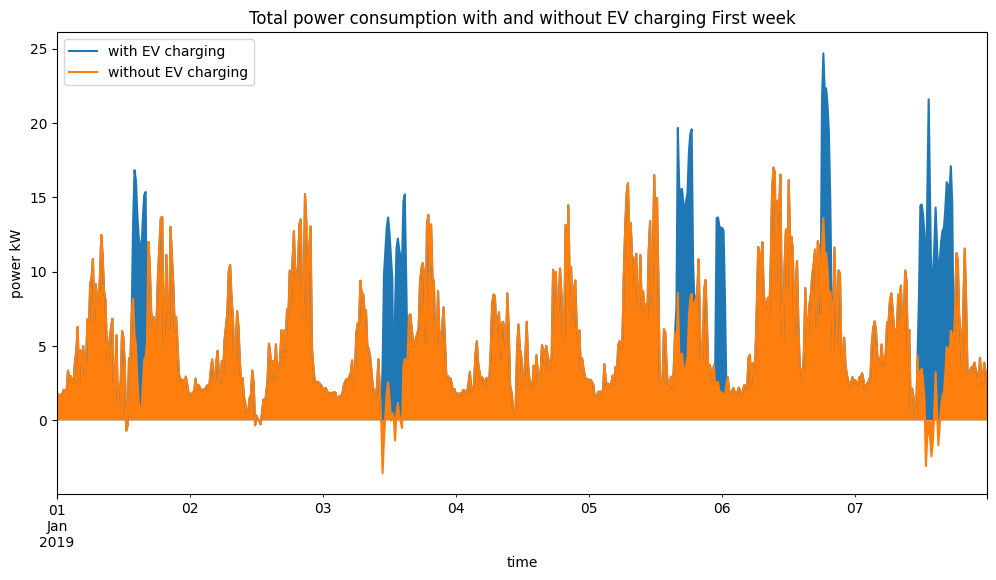

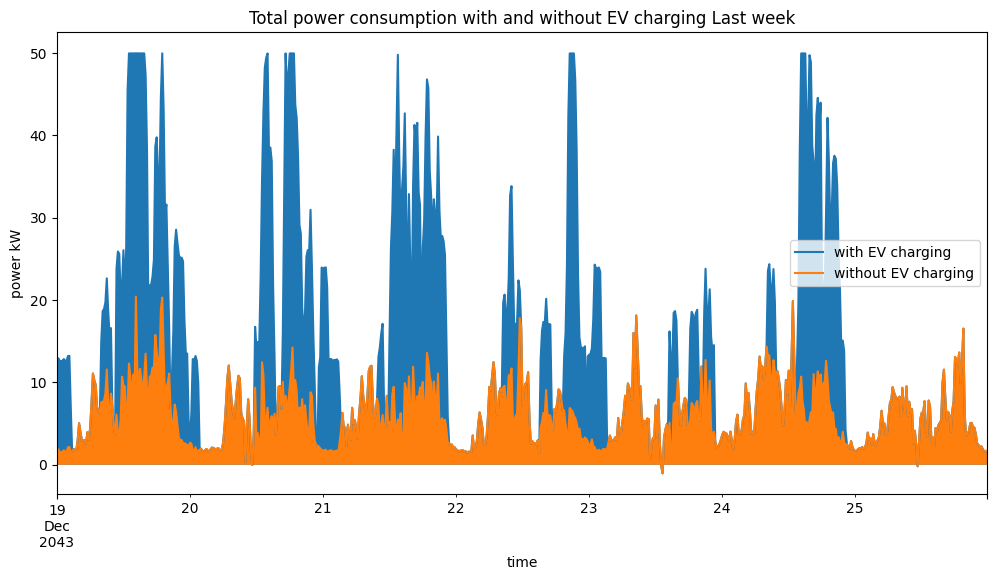

In [23]:
def plot_total_power(index, df_profiles, prosumption_lifetime, title):
  plt.figure(figsize=(12, 6))
  (df_profiles.sum(axis=1).iloc[index]*4 + prosumption_lifetime.iloc[index]*4).plot(label='with EV charging')
  plt.fill_between(df_profiles.sum(axis=1).iloc[index].index, 0, (df_profiles.sum(axis=1).iloc[index]+prosumption_lifetime.iloc[index])*4, alpha=1.0)
  (prosumption_lifetime.iloc[index]*4).plot(label='without EV charging')
  plt.fill_between(df_profiles.sum(axis=1).iloc[index].index, 0, prosumption_lifetime.iloc[index]*4, alpha=1.0)
  plt.title(f'Total power consumption with and without EV charging {title}')
  plt.legend()
  plt.xlabel('time')

  plt.ylabel('power kW')

plot_total_power(slice(0, 96*7), df_profiles, prosumption_lifetime, 'First week')
plot_total_power(slice(-96*7, None), df_profiles, prosumption_lifetime, 'Last week')

## Associamo i singoli veicoli agli appartamenti e generiamo un nuovo con i carichi degli appartamenti al netto della carica EV
Mettiamo massimo 2 EV ad appartamento

In [24]:
consumption_lifetime_ev = consumption_lifetime.copy()


evs = list(df_profiles.columns)
meters = list(consumption_lifetime_ev.columns)

# Ensure that there are enough meter slots for all EVs.
if len(evs) > 2 * len(meters):
    raise ValueError("There are more EVs than available meter slots (max 2 EVs per meter).")

# Create a list that repeats each meter twice (each meter has 2 slots).
meter_slots = meters * 2

# Shuffle the meter slot list.
np.random.shuffle(meter_slots)

# Assign each EV a meter from the first len(evs) elements.
ev_to_meter = {ev: meter_slots[i] for i, ev in enumerate(evs)}

print(ev_to_meter)

for ev in evs:
  meter = ev_to_meter[ev]
  consumption_lifetime_ev[meter] += df_profiles[ev]

print(consumption_lifetime.sum(axis=0))
print(consumption_lifetime_ev.sum(axis=0))

{'027_001': 'meter_0021', '006_001': 'meter_0010', '035_001': 'meter_0005', '018_001': 'meter_0018', '035_002': 'meter_0004', '022_001': 'meter_0009', '020_001': 'meter_0017', '046_001': 'meter_0015', '049_001': 'meter_0027', '045_001': 'meter_0012', '005_002': 'meter_0003', '006_002': 'meter_0029', '024_001': 'meter_0007', '041_001': 'meter_0007', '043_001': 'meter_0017', '031_001': 'meter_0014', '028_001': 'meter_0013', '048_001': 'meter_0016', '005_001': 'meter_0020', '004_001': 'meter_0025', '019_002': 'meter_0006', '051_001': 'meter_0011', '011_001': 'meter_0024', '050_001': 'meter_0028', '042_001': 'meter_0021', '023_001': 'meter_0029', '043_002': 'meter_0014', '009_001': 'meter_0016', '014_002': 'meter_0018', '012_001': 'meter_0002'}
meter_0001    58027.539097
meter_0002    31603.559923
meter_0003    63098.965923
meter_0004    29772.959250
meter_0005    61836.660601
meter_0006    24998.518445
meter_0007    25462.736148
meter_0008    16500.521607
meter_0009    25798.582757
meter_

## Scarichiamo i profili di consumo aggiornati

In [25]:
save_path = f'consumption_lifetime_ev_{max_A_single_charger}A_{max_P_building[-1]}kW.csv'
print(save_path)
# save the dataframe to a csv file
consumption_lifetime_ev.to_csv(save_path, sep=',', date_format='%Y-%m-%dT%H:%M:%S', float_format='%.03f')
# this downloads the csv file onto your local machine
files.download(save_path)

consumption_lifetime_ev_16A_50kW.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
save_path = 'production_lifetime.csv'
production_lifetime.to_csv(save_path, sep=',', date_format='%Y-%m-%dT%H:%M:%S', float_format='%.03f')
# this downloads the csv file onto your local machine
files.download('production_lifetime.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Scarichiamo i profili di produzione